# Customer Churn Prediction

# Business Understanding

# Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Code to create kaggle path for data download
# Code taken from stackoverflow user fdsig
import json
import os
from pathlib import Path

# your api key
api_key = {
'username':"",
'key':""}

# uses pathlib Path
kaggle_path = Path('/root/.kaggle')
os.makedirs(kaggle_path, exist_ok=True)

# opens file and dumps python dict to json object
with open (kaggle_path/'kaggle.json', 'w') as handl:
    json.dump(api_key,handl)

os.chmod(kaggle_path/'kaggle.json', 600)

In [3]:
# Downloading kaggle dataset
# Cell output cleared as only contains data download progress
!kaggle datasets download -d muhammadshahidazeem/customer-churn-dataset

# Creating parent folder directory for data unzip
!unzip customer-churn-dataset.zip -d customer-churn-dataset

Dataset URL: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset
License(s): GPL-2.0
100% 6.66M/6.66M [00:00<00:00, 221MB/s]

Archive:  customer-churn-dataset.zip
  inflating: customer-churn-dataset/customer_churn_dataset-testing-master.csv  
  inflating: customer-churn-dataset/customer_churn_dataset-training-master.csv  


In [4]:
train_data = pd.read_csv('/content/customer-churn-dataset/customer_churn_dataset-training-master.csv')
test_data = pd.read_csv('/content/customer-churn-dataset/customer_churn_dataset-testing-master.csv')

In [5]:
train_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
test_data.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [7]:
[train_data.info()], [test_data.info()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  D

([None], [None])

In [8]:
train_data.isna().sum(), test_data.isna().sum()

(CustomerID           1
 Age                  1
 Gender               1
 Tenure               1
 Usage Frequency      1
 Support Calls        1
 Payment Delay        1
 Subscription Type    1
 Contract Length      1
 Total Spend          1
 Last Interaction     1
 Churn                1
 dtype: int64,
 CustomerID           0
 Age                  0
 Gender               0
 Tenure               0
 Usage Frequency      0
 Support Calls        0
 Payment Delay        0
 Subscription Type    0
 Contract Length      0
 Total Spend          0
 Last Interaction     0
 Churn                0
 dtype: int64)

In [9]:
train_data['Churn'].value_counts()

,count
Churn,
1.0,249999
0.0,190833


In [10]:
test_data['Churn'].value_counts()

,count
Churn,
0,33881
1,30493


## Data Preprocessing

In [11]:
# Dropping single NaN row
train_data = train_data.dropna()
train_data[train_data['CustomerID'].isna()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn


In [12]:
# Combining test and train data
df = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505201,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505202,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505203,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505204,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [13]:
# Lowercasing and replacing whitespace in columns
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['customerid', 'age', 'gender', 'tenure', 'usage_frequency',
       'support_calls', 'payment_delay', 'subscription_type',
       'contract_length', 'total_spend', 'last_interaction', 'churn'],
      dtype='object')

In [14]:
# Converting non-monetary numbers to integer dtype
col_list = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']

for col in col_list:
  df[col] = df[col].astype('int64')

In [15]:
df

,customerid,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,2.0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,3.0,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,4.0,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,5.0,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,6.0,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...
505201,64370.0,45,Female,33,12,6,21,Basic,Quarterly,947.0,14,1
505202,64371.0,37,Male,6,1,5,22,Standard,Annual,923.0,9,1
505203,64372.0,25,Male,39,14,8,30,Premium,Monthly,327.0,20,1
505204,64373.0,50,Female,18,19,7,22,Standard,Monthly,540.0,13,1


## Exploratory data Analysis

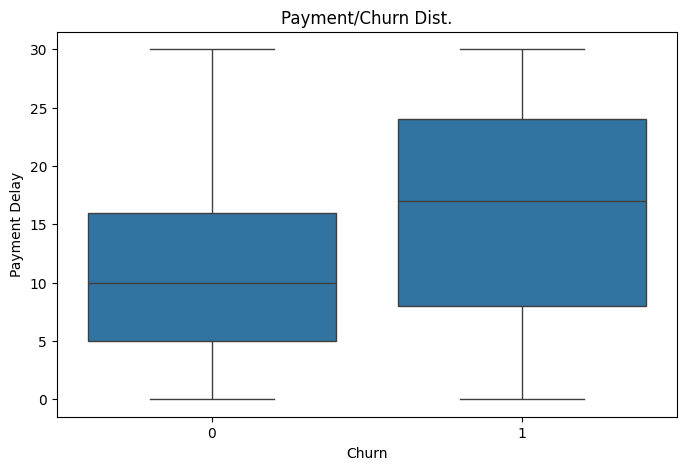

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(df, x='churn', y= 'payment_delay')

ax.set_title('Payment/Churn Dist.')
ax.set_xlabel('Churn')
ax.set_ylabel('Payment Delay');

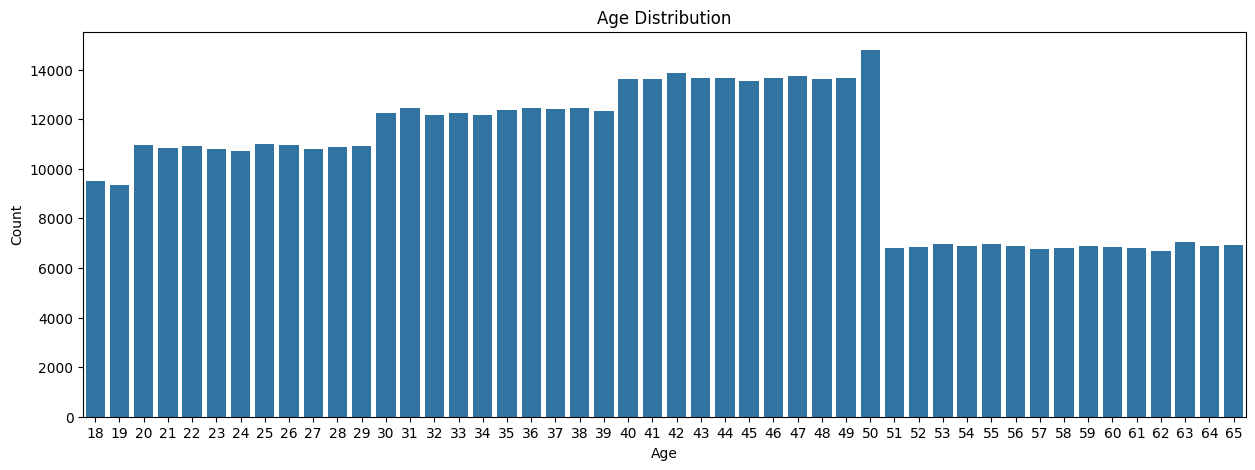

In [17]:
age_dict_vc = dict(df['age'].value_counts())
age_values = list(age_dict_vc.values())
age_keys = list(age_dict_vc.keys())

fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(x=age_keys, y=age_values, ax=ax)

ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count');

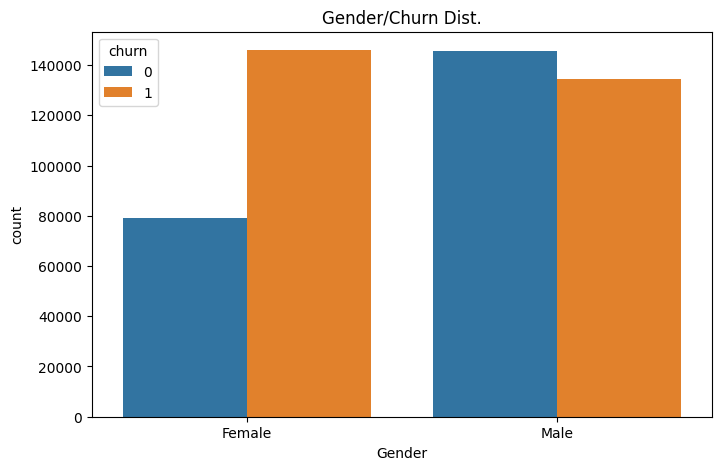

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(df, x='gender', hue='churn')

ax.set_title('Gender/Churn Dist.')
ax.set_xlabel('Gender');

# Data Preparation

# Modeling

# Evaluation

## Limitations

## Next Steps

# Conclusion